In [ ]:
import os
import numpy as np
import pandas as pd


def build_powerplant(csv_path="powerplant.csv", seed=13, verbose=False):
    """Combined-cycle power plant: predict net electrical power output (MW) from
    ambient conditions. A genuinely nonlinear regression problem — ideal for
    studying optimisers, model complexity, regularisation and bias-variance.

    Features:
      AT  ambient temperature (deg C)
      V   exhaust vacuum (cm Hg)
      AP  ambient pressure (millibar)
      RH  relative humidity (%)
    Target:
      PE  net hourly electrical energy output (MW)
    """
    rng = np.random.default_rng(seed)
    N = 2000
    AT = rng.uniform(2, 37, N)
    V = np.clip(18 + 1.45 * AT + rng.normal(0, 6, N), 25, 82)
    AP = np.clip(rng.normal(1013, 6, N), 992, 1034)
    RH = np.clip(rng.uniform(25, 100, N), 25, 100)

    # output falls with temperature & vacuum; mild curvature in AT (so degree-2 beats degree-1)
    PE = (482
          - 1.7 * AT
          - 0.20 * (V - 50)
          + 0.07 * (AP - 1013)
          + 0.02 * (RH - 60)
          - 0.010 * (AT - 18) ** 2
          + rng.normal(0, 4, N))
    df = pd.DataFrame({
        "AT": AT.round(2), "V": V.round(2), "AP": AP.round(2),
        "RH": RH.round(2), "PE": PE.round(2),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("powerplant:", df.shape)
        print("PE range:", df.PE.min(), "-", df.PE.max())
        print("corr with PE:\n", df.corr()["PE"].round(3).to_string())
    return df

if not os.path.exists('powerplant.csv'):
    build_powerplant(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
df = pd.read_csv('powerplant.csv')
X = df[['AT', 'V', 'AP', 'RH']].values
y = df['PE'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
df.head(3)

Generated dataset file.
train: (1500, 4) | test: (500, 4)


,AT,V,AP,RH,PE
0,32.27,62.90,1022.72,93.71,421.37
1,31.94,71.15,1015.86,45.62,417.67
2,30.39,66.95,1018.97,39.47,420.28


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


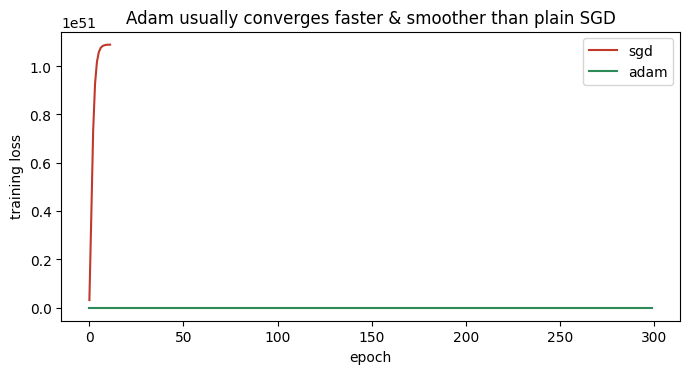

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
Xtr = StandardScaler().fit_transform(X_train)   # neural nets need scaled inputs

fig, ax = plt.subplots(figsize=(7, 4))
for solver, col in [('sgd', '#C0392B'), ('adam', '#2E8B57')]:
    nn = MLPRegressor(hidden_layer_sizes=(32, 16), solver=solver,
                      learning_rate_init=0.01, max_iter=300, random_state=0)
    nn.fit(Xtr, y_train)
    ax.plot(nn.loss_curve_, label=solver, color=col)
ax.set_xlabel('epoch'); ax.set_ylabel('training loss'); ax.legend()
ax.set_title('Adam usually converges faster & smoother than plain SGD')
plt.tight_layout(); plt.show()

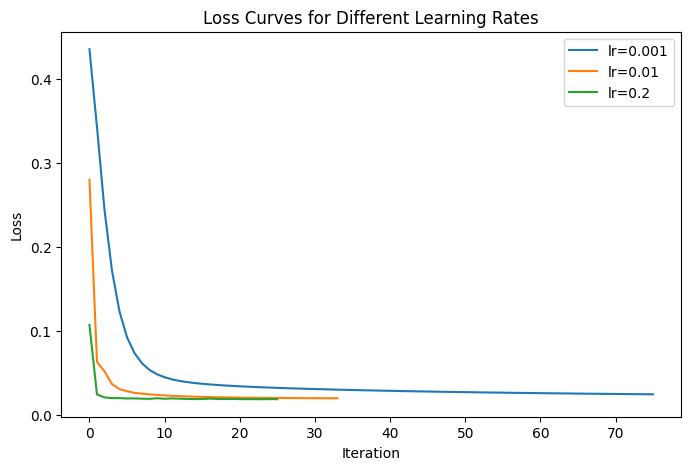

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Assume X and y are already prepared
# X = features, y = target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Scale target variable (y)
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1))

# Learning rates to compare
learning_rates = [0.001, 0.01, 0.2]

plt.figure(figsize=(8, 5))

for lr in learning_rates:
    mlp = MLPRegressor(
        hidden_layer_sizes=(50,),
        solver='sgd',
        learning_rate_init=lr,
        max_iter=100,
        random_state=42
    )

    mlp.fit(X_train_scaled, y_train_scaled.ravel()) # Use scaled y_train and flatten it

    plt.plot(
        mlp.loss_curve_,
        label=f'lr={lr}'
    )

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Curves for Different Learning Rates')
plt.legend()
plt.show()

# Comment:
# - learning_rate_init = 0.001:
#   Usually converges very slowly. Loss decreases gradually and may
#   require many more iterations to reach a good solution.
#
# - learning_rate_init = 0.01:
#   Typically a good learning rate. Loss decreases smoothly and reaches
#   a low value relatively quickly.
#
# - learning_rate_init = 0.2:
#   Often too large. Loss may oscillate, fluctuate, or even diverge,
#   indicating unstable training.
#
# Therefore:
#   0.001 → too slow
#   0.01  → good
#   0.2   → unstable

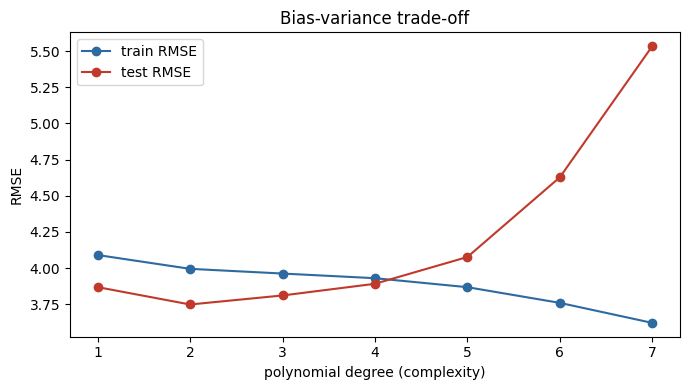

As degree rises: train error keeps falling, test error turns back up = overfitting.


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression # Import LinearRegression
from sklearn.metrics import mean_squared_error # Import mean_squared_error as it's also used
from sklearn.preprocessing import StandardScaler # Already imported in a previous cell, but good to have explicit
import matplotlib.pyplot as plt # Already imported in a previous cell, but good to have explicit

degrees = range(1, 8)
tr_err, te_err = [], []
for d in degrees:
    m = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    m.fit(X_train, y_train)
    tr_err.append(mean_squared_error(y_train, m.predict(X_train)) ** 0.5)
    te_err.append(mean_squared_error(y_test, m.predict(X_test)) ** 0.5)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(degrees), tr_err, 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(list(degrees), te_err, 'o-', label='test RMSE', color='#C0392B')
ax.set_xlabel('polynomial degree (complexity)'); ax.set_ylabel('RMSE')
ax.set_title('Bias-variance trade-off'); ax.legend(); plt.tight_layout(); plt.show()
print('As degree rises: train error keeps falling, test error turns back up = overfitting.')

In [ ]:
best_idx = np.argmin(te_err)      # index of minimum test RMSE
best_degree = degrees[best_idx]   # if you stored degrees separately

print("Best degree:", best_degree)
print("Lowest test RMSE:", te_err[best_idx])


Best degree: 2
Lowest test RMSE: 3.7490242314142033


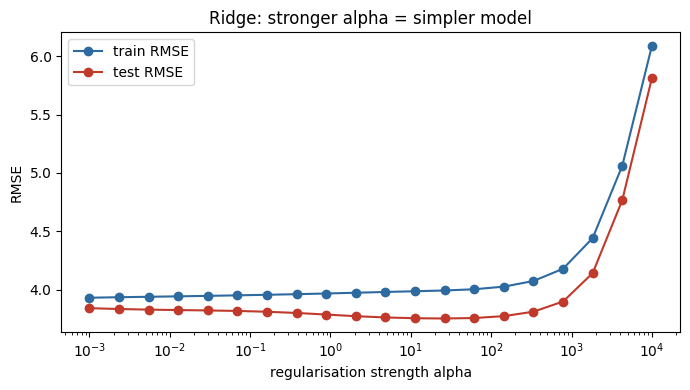

In [ ]:
# -----------------------------------------------------------
# 🔹 4A. ON A DELIBERATELY OVER-COMPLEX MODEL, VARY ALPHA
# -----------------------------------------------------------
from sklearn.linear_model import Ridge
alphas = np.logspace(-3, 4, 20)
tr, te = [], []
for a in alphas:
    m = make_pipeline(PolynomialFeatures(6), StandardScaler(), Ridge(alpha=a))
    m.fit(X_train, y_train)
    tr.append(mean_squared_error(y_train, m.predict(X_train)) ** 0.5)
    te.append(mean_squared_error(y_test, m.predict(X_test)) ** 0.5)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, tr, 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(alphas, te, 'o-', label='test RMSE', color='#C0392B')
ax.set_xscale('log'); ax.set_xlabel('regularisation strength alpha'); ax.set_ylabel('RMSE')
ax.set_title('Ridge: stronger alpha = simpler model'); ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Degree-1 features only
X = df[['AT', 'V', 'AP', 'RH']]
y = df['PE']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit Lasso
lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X_scaled, y)

# Print coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_
})

print(coef_df)

# Optional: print intercept
print("\nIntercept:", lasso.intercept_)



  Feature  Coefficient
0      AT   -17.010844
1       V    -3.194174
2      AP     0.284765
3      RH     0.470553

Intercept: 448.928245


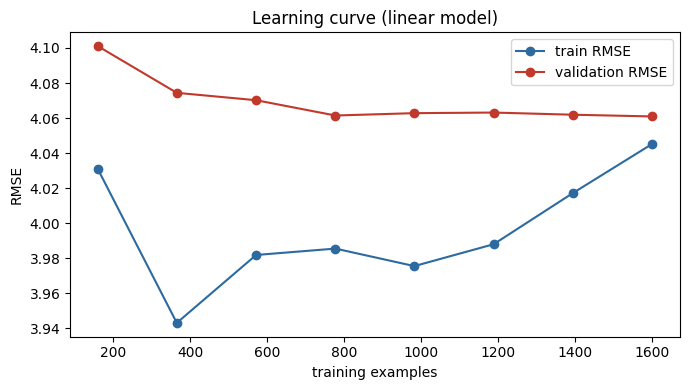

Both errors high and close => more bias-limited than variance-limited here.


In [ ]:
# -----------------------------------------------------------
# 🔹 5A. ERROR vs TRAINING-SET SIZE
# -----------------------------------------------------------
from sklearn.model_selection import learning_curve
sizes, train_sc, val_sc = learning_curve(
    LinearRegression(), X, y, cv=5, scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=0)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, -train_sc.mean(1), 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(sizes, -val_sc.mean(1), 'o-', label='validation RMSE', color='#C0392B')
ax.set_xlabel('training examples'); ax.set_ylabel('RMSE')
ax.set_title('Learning curve (linear model)'); ax.legend(); plt.tight_layout(); plt.show()
print('Both errors high and close => more bias-limited than variance-limited here.')


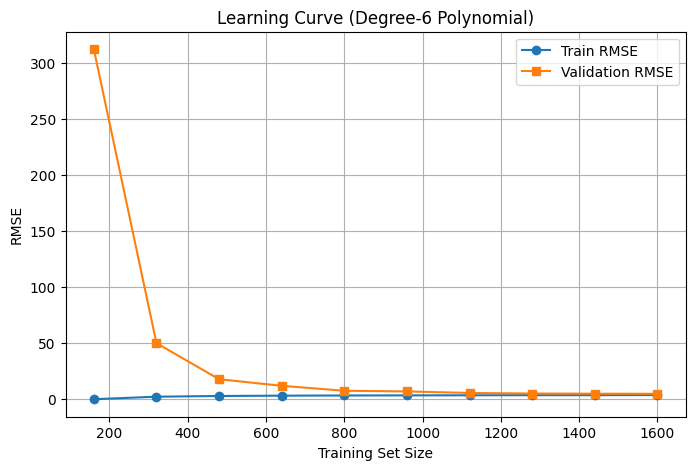

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Degree-6 polynomial model
deg6_model = Pipeline([
    ('poly', PolynomialFeatures(degree=6, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

# Learning curve
train_sizes, train_scores, val_scores = learning_curve(
    deg6_model,
    X, y,
    cv=5,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Convert from negative RMSE to RMSE
train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, marker='o', label='Train RMSE')
plt.plot(train_sizes, val_rmse, marker='s', label='Validation RMSE')

plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.title('Learning Curve (Degree-6 Polynomial)')
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
# -----------------------------------------------------------
# 🔹 6A. CHOOSE COMPLEXITY + REGULARISATION BY CROSS-VALIDATION
# -----------------------------------------------------------
from sklearn.model_selection import cross_val_score
best = None
for d in [1, 2, 3]:
    for a in [0.1, 1, 10, 100]:
        m = make_pipeline(PolynomialFeatures(d), StandardScaler(), Ridge(alpha=a))
        score = -cross_val_score(m, X_train, y_train, cv=5,
                                 scoring='neg_root_mean_squared_error').mean()
        if best is None or score < best[0]:
            best = (score, d, a)
print(f'best CV RMSE {best[0]:.2f} at degree={best[1]}, alpha={best[2]}')


best CV RMSE 4.03 at degree=3, alpha=10


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, LinearRegression # Import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

best_degree = best[1] # Extract best degree from the 'best' tuple
best_alpha = best[2]   # Extract best alpha from the 'best' tuple

# Calculate baseline RMSE and R2 from a simple linear regression
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
baseline_y_pred = baseline_model.predict(X_test)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_y_pred))
baseline_r2 = r2_score(y_test, baseline_y_pred)

# 1. Fit best config on all training data
best_model = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=best_alpha))
])

best_model.fit(X_train, y_train)

# Predict on held-out test set
y_pred = best_model.predict(X_test)

# Test metrics
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print("Best Model")
print("Degree:", best_degree)
print("Alpha :", best_alpha)
print("Test RMSE:", round(test_rmse, 3))
print("Test R² :", round(test_r2, 4))

# 2. Compare to Section-1 baseline
print("\nBaseline Model")
print("Baseline Test RMSE:", round(baseline_rmse, 3))
print("Baseline Test R² :", round(baseline_r2, 4))

print("\nImprovement")
print("RMSE Change:", round(baseline_rmse - test_rmse, 3))
print("R² Change :", round(test_r2 - baseline_r2, 4))

Best Model
Degree: 3
Alpha : 10
Test RMSE: 3.727
Test R² : 0.9658

Baseline Model
Baseline Test RMSE: 3.869
Baseline Test R² : 0.9632

Improvement
RMSE Change: 0.142
R² Change : 0.0027
